# Active Learning for Guest Satisfaction Review Classification

This notebook explores a hotel review dataset and builds toward an active learning pipeline for guest satisfaction classification. The project uses review text and ratings to create satisfaction labels, train baseline text classification models, and compare active learning strategies.

Cell 1: Adding imports for dataset loading and review

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast # Needed for converting string representations of lists to actual lists with numeric values
from pathlib import Path

# Check current directory

Path.cwd()

WindowsPath('c:/Users/mitch/Desktop/CS Project/DataScienceProjects/HotelReviews/Active-Learning-Review-Satisfication/notebooks')

Cell 2: Load the dataset

In [25]:
dataset_path = Path("../data/raw/trip_advisor_hotel_reviews.csv")

reviews_df = pd.read_csv(dataset_path)
reviews_df.head()

,ratings,title,text,author,date_stayed,offering_id,num_helpful_votes,date,id,via_mobile
0,"{'service': 5.0, 'cleanliness': 5.0, 'overall'...","“Truly is ""Jewel of the Upper Wets Side""”",Stayed in a king suite for 11 nights and yes i...,"{'username': 'Papa_Panda', 'num_cities': 22, '...",December 2012,93338,0,2012-12-17,147643103,False
1,"{'service': 5.0, 'cleanliness': 5.0, 'overall'...",“My home away from home!”,"On every visit to NYC, the Hotel Beacon is the...","{'username': 'Maureen V', 'num_reviews': 2, 'n...",December 2012,93338,0,2012-12-17,147639004,False
2,"{'service': 4.0, 'cleanliness': 5.0, 'overall'...",“Great Stay”,This is a great property in Midtown. We two di...,"{'username': 'vuguru', 'num_cities': 12, 'num_...",December 2012,1762573,0,2012-12-18,147697954,False
3,"{'service': 5.0, 'cleanliness': 5.0, 'overall'...",“Modern Convenience”,The Andaz is a nice hotel in a central locatio...,"{'username': 'Hotel-Designer', 'num_cities': 5...",August 2012,1762573,0,2012-12-17,147625723,False
4,"{'service': 4.0, 'cleanliness': 5.0, 'overall'...",“Its the best of the Andaz Brand in the US....”,I have stayed at each of the US Andaz properti...,"{'username': 'JamesE339', 'num_cities': 34, 'n...",December 2012,1762573,0,2012-12-17,147612823,False


Cell 3: Check shape

In [26]:
# Check the shape of the dataset
reviews_df.shape

(878561, 10)

Cell 4: Columns

In [27]:
# Display name of columns
reviews_df.columns

Index(['ratings', 'title', 'text', 'author', 'date_stayed', 'offering_id',
       'num_helpful_votes', 'date', 'id', 'via_mobile'],
      dtype='str')

Cell 5: Info

In [28]:
# Display data types of each column & non-null counts
reviews_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 878561 entries, 0 to 878560
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   ratings            878561 non-null  str  
 1   title              878561 non-null  str  
 2   text               878561 non-null  str  
 3   author             878561 non-null  str  
 4   date_stayed        810967 non-null  str  
 5   offering_id        878561 non-null  int64
 6   num_helpful_votes  878561 non-null  int64
 7   date               878561 non-null  str  
 8   id                 878561 non-null  int64
 9   via_mobile         878561 non-null  bool 
dtypes: bool(1), int64(3), str(6)
memory usage: 61.2 MB


Cell 6: Missing values

In [29]:
# Check for missing values
reviews_df.isnull().sum()

ratings                  0
title                    0
text                     0
author                   0
date_stayed          67594
offering_id              0
num_helpful_votes        0
date                     0
id                       0
via_mobile               0
dtype: int64

Cell 7: Summarize

In [30]:
# Summary statistics
reviews_df.describe()

,offering_id,num_helpful_votes,id
count,8.785610e+05,878561.000000,8.785610e+05
mean,3.058972e+05,1.153104,8.633481e+07
std,4.388314e+05,2.898120,4.999254e+07
min,7.257200e+04,0.000000,2.243990e+05
25%,8.999800e+04,0.000000,3.488850e+07
50%,1.114080e+05,0.000000,1.113905e+08
75%,2.416400e+05,1.000000,1.283089e+08
max,3.574675e+06,515.000000,1.478017e+08


Cell 8: Rating distribution

In [31]:
# Count how many reviews exist for each rating value
reviews_df["ratings"].value_counts().sort_index()

ratings
{'check_in_front_desk': 1.0, 'overall': 1.0, 'rooms': 1.0, 'service': 1.0, 'location': 2.0}    1
{'check_in_front_desk': 1.0, 'overall': 1.0, 'rooms': 1.0, 'value': 1.0, 'location': 1.0}      1
{'check_in_front_desk': 1.0, 'overall': 1.0, 'rooms': 1.0, 'value': 1.0, 'location': 3.0}      1
{'check_in_front_desk': 1.0, 'overall': 1.0, 'rooms': 2.0, 'value': 1.0, 'location': 1.0}      1
{'check_in_front_desk': 1.0, 'overall': 1.0, 'rooms': 3.0, 'value': 2.0, 'location': 5.0}      1
                                                                                              ..
{'value': 5.0, 'sleep_quality': 5.0, 'overall': 4.0, 'location': 5.0, 'service': 5.0}          1
{'value': 5.0, 'sleep_quality': 5.0, 'overall': 5.0, 'location': 3.0, 'service': 5.0}          1
{'value': 5.0, 'sleep_quality': 5.0, 'overall': 5.0, 'location': 4.0, 'service': 5.0}          1
{'value': 5.0, 'sleep_quality': 5.0, 'overall': 5.0, 'location': 5.0, 'service': 5.0}          1
{'value': 5.0, 'sleep_

Cell 9: Quality checks to understand how to run a plt for the distribution of the ratings faster

In [32]:
# Check the data type of the ratings column.
print(reviews_df["ratings"].dtype)
# Check how many unique rating values exist.
print(reviews_df["ratings"].nunique())
# See the first few unique rating values.
print(reviews_df["ratings"].unique()[:20])

str
55523
<StringArray>
['{'service': 5.0, 'cleanliness': 5.0, 'overall': 5.0, 'value': 5.0, 'location': 5.0, 'sleep_quality': 5.0, 'rooms': 5.0}',
 '{'service': 4.0, 'cleanliness': 5.0, 'overall': 4.0, 'value': 4.0, 'location': 5.0, 'sleep_quality': 4.0, 'rooms': 4.0}',
 '{'service': 5.0, 'cleanliness': 5.0, 'overall': 4.0, 'value': 5.0, 'location': 5.0, 'sleep_quality': 5.0, 'rooms': 5.0}',
 '{'service': 4.0, 'cleanliness': 5.0, 'overall': 4.0, 'value': 3.0, 'location': 5.0, 'sleep_quality': 5.0, 'rooms': 5.0}',
 '{'service': 5.0, 'cleanliness': 5.0, 'overall': 5.0, 'value': 4.0, 'location': 5.0, 'sleep_quality': 4.0, 'rooms': 5.0}',
                       '{'service': 5.0, 'cleanliness': 5.0, 'overall': 5.0, 'value': 4.0, 'rooms': 5.0, 'location': 4.0}',
 '{'service': 5.0, 'cleanliness': 5.0, 'overall': 5.0, 'value': 4.0, 'location': 5.0, 'sleep_quality': 5.0, 'rooms': 5.0}',
 '{'service': 4.0, 'cleanliness': 5.0, 'overall': 4.0, 'value': 4.0, 'location': 5.0, 'sleep_quality': 5.0, 

This is way too many unique values which is due to the "ratings" reviews being strings and having every single review be unique. Importing ast I am able to convert this column into an actual python dictionary.

In [33]:
def extract_overall_rating(rating_str):
    try:
        # Convert the string representation of a dictionary to an actual dictionary
        rating_dict = ast.literal_eval(rating_str)
        # Extract the "overall" key as the overall rating
        overall_rating = rating_dict.get("overall")
        return overall_rating
    except (ValueError, SyntaxError):
        return np.nan  # Return NaN if conversion fails
    
# Apply the function to the ratings column to create a new column for overall ratings
reviews_df["overall_rating"] = reviews_df["ratings"].apply(extract_overall_rating)
# Check the first few values of the new overall_rating column
reviews_df[["ratings", "overall_rating"]].head()

,ratings,overall_rating
0,"{'service': 5.0, 'cleanliness': 5.0, 'overall'...",5.0
1,"{'service': 5.0, 'cleanliness': 5.0, 'overall'...",5.0
2,"{'service': 4.0, 'cleanliness': 5.0, 'overall'...",4.0
3,"{'service': 5.0, 'cleanliness': 5.0, 'overall'...",4.0
4,"{'service': 4.0, 'cleanliness': 5.0, 'overall'...",4.0


Cell : Rating chart:

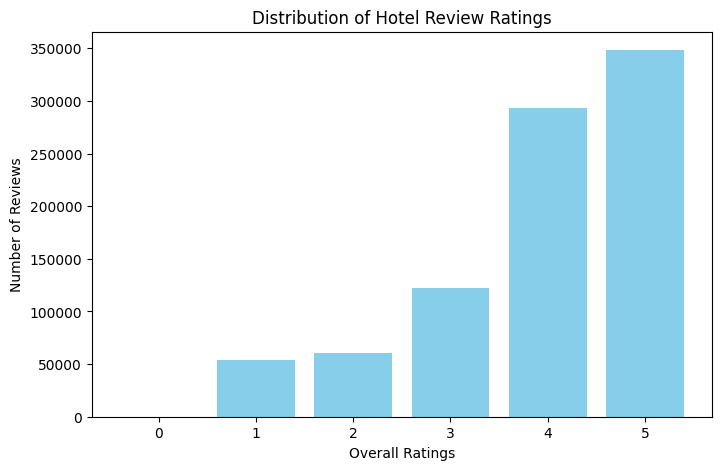

In [34]:
# Plot the distribution of ratings
plt.figure(figsize=(8, 5))
ratings_counts = reviews_df["overall_rating"].value_counts().sort_index()
plt.bar(ratings_counts.index, ratings_counts.values, color="skyblue")
plt.xlabel("Overall Ratings")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Hotel Review Ratings")
plt.xticks(ratings_counts.index)
plt.show()

## Initial Observations

The dataset was loaded successfully and contains hotel review data with a `ratings` column stored as a string representation of a dictionary. Because the project needs a single satisfaction label, the `overall` rating was extracted into a new `overall_rating` column.

The distribution of overall ratings shows how many reviews fall into each rating category. This will be used in the next step to create a binary satisfaction label for classification.

## Review Cleaning and Satisfaction Label Creation

This section prepares the review data for text classification. The `overall_rating` column is used to create a binary satisfaction label, where lower ratings represent dissatisfied reviews and higher ratings represent satisfied reviews.

Cell 1: 

In [35]:
text_column = "text"
rating_column = "overall_rating"

# Check for any null values in the text and rating columns
print(reviews_df[[text_column, rating_column]].isnull().sum())

text              0
overall_rating    0
dtype: int64


Cell 2: Copy frame

In [36]:
# Create a copy to clean
clean_reviews_df = reviews_df.copy()
# Keep only rows text and overall_rating
clean_reviews_df = clean_reviews_df.dropna(subset=[text_column, rating_column])
# Check the shape after dropping nulls
print(clean_reviews_df.shape)

(878561, 11)


Cell 3: Create binary satisfaction label

In [37]:
# 1 = Satisfied review, 0 = Unsatisfied review
clean_reviews_df["satisfaction_label"] = np.where(
    clean_reviews_df["overall_rating"] >= 4, 
    1, 
    0
)
# Check first few rows
clean_reviews_df[["overall_rating", "satisfaction_label"]].head()

,overall_rating,satisfaction_label
0,5.0,1
1,5.0,1
2,4.0,1
3,4.0,1
4,4.0,1


Cell 4: Check distribution of satisfaction labels

In [38]:
label_counts = clean_reviews_df["satisfaction_label"].value_counts()

label_counts.round(2)

satisfaction_label
1    642046
0    236515
Name: count, dtype: int64

Cell 5: Plot the label distribution

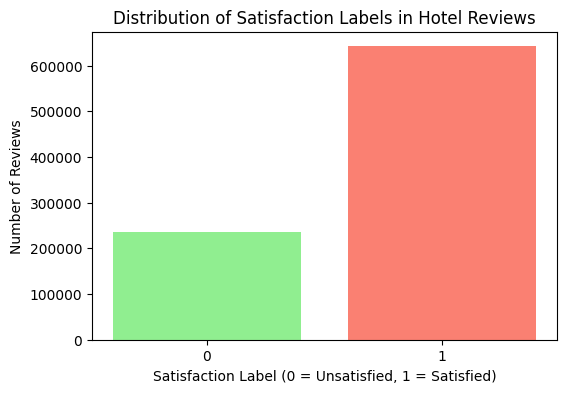

In [39]:
label_counts.sort_index()

plt.figure(figsize=(6, 4))
plt.bar(label_counts.index, label_counts.values, color=["salmon", "lightgreen"])
plt.xlabel("Satisfaction Label (0 = Unsatisfied, 1 = Satisfied)")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Satisfaction Labels in Hotel Reviews")
plt.xticks(label_counts.index)
plt.show()

Cell 6: Text cleaning

In [40]:
# Convert review text to string type (if not already)
clean_reviews_df["clean_text"] = (
    clean_reviews_df[text_column].astype(str)
    .str.lower()
    .str.replace(r'[^\w\s]', '', regex=True)
    .str.strip()
)
# Check first few rows of the cleaned text
clean_reviews_df[["text", "clean_text"]].head()

,text,clean_text
0,Stayed in a king suite for 11 nights and yes i...,stayed in a king suite for 11 nights and yes i...
1,"On every visit to NYC, the Hotel Beacon is the...",on every visit to nyc the hotel beacon is the ...
2,This is a great property in Midtown. We two di...,this is a great property in midtown we two dif...
3,The Andaz is a nice hotel in a central locatio...,the andaz is a nice hotel in a central locatio...
4,I have stayed at each of the US Andaz properti...,i have stayed at each of the us andaz properti...


Cell 7: Save processed data to processed folder

In [41]:
processed_path = Path("../data/processed/clean_reviews.csv")
clean_reviews_df.to_csv(processed_path, index=False)

processed_path

WindowsPath('../data/processed/clean_reviews.csv')

## Cleaning and Labeling Summary

The review dataset was cleaned by removing rows missing review text or overall rating values. A binary `satisfaction_label` was created from the extracted `overall_rating` column, where ratings of 4 or 5 were labeled as satisfied and ratings below 4 were labeled as dissatisfied. Basic text normalization was applied by lowercasing review text and removing extra whitespace.

This prepared dataset will be used for the baseline text classification model.

## Baseline Text Classification

This section trains a baseline text classification model to predict guest satisfaction from hotel review text. The model uses TF-IDF features to represent review text numerically and Logistic Regression as the first baseline classifier.

Cell 1: Import needed sklearn libraries

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

Cell 2: Define text features and target labels

In [ ]:
text_features = clean_reviews_df["clean_text"] #What the model reads
target_labels = clean_reviews_df["satisfaction_label"] #Learn to predict this

text_features.head(), target_labels.head()

(0    stayed in a king suite for 11 nights and yes i...
 1    on every visit to nyc the hotel beacon is the ...
 2    this is a great property in midtown we two dif...
 3    the andaz is a nice hotel in a central locatio...
 4    i have stayed at each of the us andaz properti...
 Name: clean_text, dtype: str,
 0    1
 1    1
 2    1
 3    1
 4    1
 Name: satisfaction_label, dtype: int64)

Cell 3: Split into training and test sets

In [47]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    text_features, 
    target_labels, 
    test_size=0.2, 
    random_state=42,
    stratify=target_labels
)

X_train_text.shape, X_test_text.shape, y_train.shape, y_test.shape

((702848,), (175713,), (702848,), (175713,))

Cell 4: Turn text into TF-IDF features (numbers)

In [48]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,  # Limit to top 5000 features
    ngram_range=(1, 2),  # Use unigrams and bigrams
    stop_words="english",
    min_df=5
)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)
X_test_tfidf = tfidf_vectorizer.transform(X_test_text)

X_test_tfidf.shape, X_train_tfidf.shape

((175713, 5000), (702848, 5000))

Cell 5: Train logistic regression model

In [49]:
text_logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

text_logistic_model.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

Cell 6: Generate predictions

In [50]:
text_logistic_predictions = text_logistic_model.predict(X_test_tfidf)

text_logistic_predictions[:10]

array([0, 1, 0, 0, 1, 1, 1, 1, 1, 0])

Cell 7: Evaluate the model

In [52]:
baseline_text_results = {
    "accuracy": accuracy_score(y_test, text_logistic_predictions),
    "precision": precision_score(y_test, text_logistic_predictions),
    "recall": recall_score(y_test, text_logistic_predictions),
    "f1_score": f1_score(y_test, text_logistic_predictions)
}

baseline_text_results

print(classification_report(
    y_test,
    text_logistic_predictions,
    target_names=["Dissatisfied", "Satisfied"]
))

              precision    recall  f1-score   support

Dissatisfied       0.70      0.86      0.77     47303
   Satisfied       0.94      0.86      0.90    128410

    accuracy                           0.86    175713
   macro avg       0.82      0.86      0.84    175713
weighted avg       0.88      0.86      0.87    175713



## Baseline Text Classification Results

The baseline Logistic Regression model using TF-IDF features achieved 86% accuracy on the test set. Because the dataset contains more satisfied reviews than dissatisfied reviews, accuracy alone is not enough to evaluate performance. The classification report shows that the model performed well on both classes, with a average recall of 0.86.

For dissatisfied reviews, the model achieved 0.70 precision and 0.86 recall. This means the model was able to identify most dissatisfied reviews, although some reviews predicted as dissatisfied were actually satisfied. This is useful in a guest satisfaction context because identifying negative or lower-satisfaction experiences is often especially important.

For satisfied reviews, the model achieved 0.94 precision and 0.86 recall, showing strong performance on the majority class. Overall, this baseline provides a strong comparison point for the active learning experiments

Cell 8: Create confusion matrix

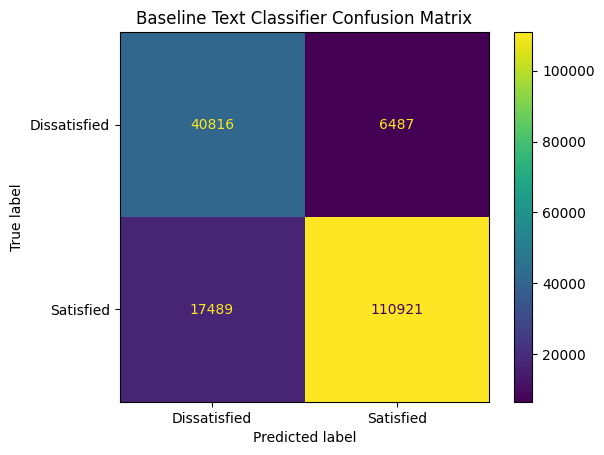

In [53]:
text_confusion_matrix = confusion_matrix(y_test, text_logistic_predictions)

text_display = ConfusionMatrixDisplay(
    confusion_matrix=text_confusion_matrix,
    display_labels=["Dissatisfied", "Satisfied"]
)

text_display.plot(values_format="d")
plt.title("Baseline Text Classifier Confusion Matrix")
plt.savefig("../visuals/baseline_text_confusion_matrix.png", bbox_inches="tight")
plt.show()

## Baseline Text Classification Summary

A baseline Logistic Regression model was trained using TF-IDF features from the cleaned hotel review text. This model provides an initial benchmark for predicting whether a review reflects a satisfied or dissatisfied guest. The results will be used as a comparison point for the active learning experiments in later sections.

## Active Learning Simulation

This section simulates an active learning workflow for guest satisfaction classification. Instead of assuming all labeled data is available at once, the experiment begins with a small labeled training set and a larger unlabeled pool.

Two sampling strategies are compared:

1. Random sampling, where new examples are selected at random.
2. Uncertainty sampling, where the model selects the reviews it is least confident about.

The goal is to test whether uncertainty sampling can improve model performance more efficiently than random sampling when only a limited number of reviews can be labeled.

Cell 1: Additional import

In [54]:
# clone allows a fresh copy of the model to be created each round for cleaner results
from sklearn.base import clone

Cell 2: Create a smaller experiment dataset

In [55]:
# A smaller sample will be used for quicker execution during active learning iterations
active_learning_df = clean_reviews_df.sample(
    n=50000,
    random_state=42
).reset_index(drop=True)

active_learning_df["satisfaction_label"].value_counts(normalize=True).round(3)

satisfaction_label
1    0.729
0    0.271
Name: proportion, dtype: float64

Cell 3: Define text and labels

In [56]:
active_text = active_learning_df["clean_text"]
active_labels = active_learning_df["satisfaction_label"]

Cell 4: Create a training and testing set

In [57]:
# Pool are examples that could be labeled during active learning, and test set are final evaluation data that remain unlabeled until the end for final evaluation of the active learning process
X_pool_text, X_test_text_active, y_pool, y_test_active = train_test_split(
    active_text,
    active_labels,
    test_size=0.20,
    random_state=42,
    stratify=active_labels
)

X_pool_text.shape, X_test_text_active.shape

((40000,), (10000,))

Cell 4: Convert text to TFIDF (Samller than last time)

In [58]:
# Smaller set up for quicker execution
active_tfidf_vectorizer = TfidfVectorizer(
    max_features=3000,
    stop_words="english",
    ngram_range=(1, 1),
    min_df=5
)

X_pool_tfidf = active_tfidf_vectorizer.fit_transform(X_pool_text)
X_test_tfidf_active = active_tfidf_vectorizer.transform(X_test_text_active)

X_pool_tfidf.shape, X_test_tfidf_active.shape

((40000, 3000), (10000, 3000))

Cell 5: Convert labels to arrays

In [59]:
y_pool_array = y_pool.to_numpy()
y_test_active_array = y_test_active.to_numpy()

Cell 6: Create helper function to evaluate model

In [70]:
def train_and_evaluate_model(X_train_subset, y_train_subset, X_test, y_test):
    model = LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    )

    model.fit(X_train_subset, y_train_subset)

    predictions = model.predict(X_test)

    results = {
        "accuracy": accuracy_score(y_test, predictions),
        "precision": precision_score(y_test, predictions),
        "recall": recall_score(y_test, predictions),
        "f1_score": f1_score(y_test, predictions),
        "dissatisfied_recall": recall_score(y_test, predictions, pos_label=0),
        "satisfied_recall": recall_score(y_test, predictions, pos_label=1)
    }

    return model, results

### Uncertainty Sampling

Uncertainty sampling selects examples where the model is least confident. For binary classification, the model is most uncertain when the predicted probability is closest to 0.50.

For example:

- Predicted probability = 0.99 → model is very confident
- Predicted probability = 0.51 → model is uncertain
- Predicted probability = 0.50 → model is maximally uncertain

In this simulation, uncertainty is measured by how close the predicted probability is to 0.50.

Cell 7: Setup active learning

In [71]:
initial_label_size = 1000 # How many we pretend are labeled at the start
query_size = 1000 # How many new examples we label each round
n_rounds = 10 # How many rounds of active learning to perform

random_num_gen = np.random.default_rng(42)

all_indices = np.arange(X_pool_tfidf.shape[0])

# Create the same initial labeled set for both random sampling and uncertainty sampling.
initial_labeled_indices = random_num_gen.choice(
    all_indices,
    size=initial_label_size,
    replace=False
)

initial_unlabeled_indices = np.setdiff1d(all_indices, initial_labeled_indices)

initial_label_size, len(initial_unlabeled_indices)

(1000, 39000)

Cell 8: Random Sampling

In [72]:
random_labeled_indices = initial_labeled_indices.copy()
random_unlabeled_indices = initial_unlabeled_indices.copy()

random_results = []

for round_number in range(n_rounds + 1):
    X_train_subset = X_pool_tfidf[random_labeled_indices]
    y_train_subset = y_pool_array[random_labeled_indices]

    model, results = train_and_evaluate_model(
        X_train_subset,
        y_train_subset,
        X_test_tfidf_active,
        y_test_active_array
    )

    results["round"] = round_number
    results["labeled_examples"] = len(random_labeled_indices)
    results["strategy"] = "Random Sampling"
    random_results.append(results)

    if round_number == n_rounds:
        break

    new_indices = random_num_gen.choice(
        random_unlabeled_indices,
        size=query_size,
        replace=False
    )

    random_labeled_indices = np.concatenate([random_labeled_indices, new_indices])
    random_unlabeled_indices = np.setdiff1d(random_unlabeled_indices, new_indices)

random_results_df = pd.DataFrame(random_results)
random_results_df

,accuracy,precision,recall,f1_score,dissatisfied_recall,satisfied_recall,round,labeled_examples,strategy
0,0.8236,0.884530,0.871914,0.878177,0.693501,0.871914,0,1000,Random Sampling
1,0.8342,0.900939,0.868075,0.884202,0.742984,0.868075,1,2000,Random Sampling
2,0.8344,0.910309,0.857378,0.883051,0.772526,0.857378,2,3000,Random Sampling
3,0.8383,0.914173,0.858886,0.885668,0.782866,0.858886,3,4000,Random Sampling
4,0.8355,0.917616,0.850795,0.882943,0.794313,0.850795,4,5000,Random Sampling
5,0.8384,0.919947,0.852578,0.884982,0.800222,0.852578,5,6000,Random Sampling
6,0.8424,0.924161,0.853950,0.887669,0.811300,0.853950,6,7000,Random Sampling
7,0.8431,0.923361,0.855869,0.888335,0.808715,0.855869,7,8000,Random Sampling
8,0.8448,0.925185,0.856418,0.889474,0.813516,0.856418,8,9000,Random Sampling
9,0.8438,0.923817,0.856418,0.888841,0.809823,0.856418,9,10000,Random Sampling


Cell 9: Uncertainty Sampling

In [73]:
uncertainty_labeled_indices = initial_labeled_indices.copy()
uncertainty_unlabeled_indices = initial_unlabeled_indices.copy()

uncertainty_results = []

for round_number in range(n_rounds + 1):
    X_train_subset = X_pool_tfidf[uncertainty_labeled_indices]
    y_train_subset = y_pool_array[uncertainty_labeled_indices]

    model, results = train_and_evaluate_model(
        X_train_subset,
        y_train_subset,
        X_test_tfidf_active,
        y_test_active_array
    )

    results["round"] = round_number
    results["labeled_examples"] = len(uncertainty_labeled_indices)
    results["strategy"] = "Uncertainty Sampling"
    uncertainty_results.append(results)

    if round_number == n_rounds:
        break

    # Get predicted probabilities for the unlabeled pool.
    unlabeled_probabilities = model.predict_proba(
        X_pool_tfidf[uncertainty_unlabeled_indices]
    )[:, 1]

    # Select examples closest to 0.50 probability.
    uncertainty_scores = np.abs(unlabeled_probabilities - 0.50)

    most_uncertain_positions = np.argsort(uncertainty_scores)[:query_size]

    new_indices = uncertainty_unlabeled_indices[most_uncertain_positions]

    uncertainty_labeled_indices = np.concatenate([
        uncertainty_labeled_indices,
        new_indices
    ])

    uncertainty_unlabeled_indices = np.setdiff1d(
        uncertainty_unlabeled_indices,
        new_indices
    )

uncertainty_results_df = pd.DataFrame(uncertainty_results)
uncertainty_results_df

,accuracy,precision,recall,f1_score,dissatisfied_recall,satisfied_recall,round,labeled_examples,strategy
0,0.8236,0.884530,0.871914,0.878177,0.693501,0.871914,0,1000,Uncertainty Sampling
1,0.8428,0.897443,0.885628,0.891496,0.727474,0.885628,1,2000,Uncertainty Sampling
2,0.8477,0.904275,0.884805,0.894434,0.747784,0.884805,2,3000,Uncertainty Sampling
3,0.8562,0.907093,0.894405,0.900704,0.753323,0.894405,3,4000,Uncertainty Sampling
4,0.8549,0.907379,0.892074,0.899661,0.754801,0.892074,4,5000,Uncertainty Sampling
5,0.8629,0.912154,0.898519,0.905285,0.766987,0.898519,5,6000,Uncertainty Sampling
6,0.8627,0.910985,0.899616,0.905265,0.763294,0.899616,6,7000,Uncertainty Sampling
7,0.8670,0.913683,0.902907,0.908263,0.770310,0.902907,7,8000,Uncertainty Sampling
8,0.8654,0.913146,0.901125,0.907096,0.769202,0.901125,8,9000,Uncertainty Sampling
9,0.8669,0.914131,0.902222,0.908137,0.771787,0.902222,9,10000,Uncertainty Sampling


Cell 10: Combine the above results

In [74]:
active_learning_results = pd.concat(
    [random_results_df, uncertainty_results_df],
    ignore_index=True
)

active_learning_results

,accuracy,precision,recall,f1_score,dissatisfied_recall,satisfied_recall,round,labeled_examples,strategy
0,0.8236,0.884530,0.871914,0.878177,0.693501,0.871914,0,1000,Random Sampling
1,0.8342,0.900939,0.868075,0.884202,0.742984,0.868075,1,2000,Random Sampling
2,0.8344,0.910309,0.857378,0.883051,0.772526,0.857378,2,3000,Random Sampling
3,0.8383,0.914173,0.858886,0.885668,0.782866,0.858886,3,4000,Random Sampling
4,0.8355,0.917616,0.850795,0.882943,0.794313,0.850795,4,5000,Random Sampling
5,0.8384,0.919947,0.852578,0.884982,0.800222,0.852578,5,6000,Random Sampling
6,0.8424,0.924161,0.853950,0.887669,0.811300,0.853950,6,7000,Random Sampling
7,0.8431,0.923361,0.855869,0.888335,0.808715,0.855869,7,8000,Random Sampling
8,0.8448,0.925185,0.856418,0.889474,0.813516,0.856418,8,9000,Random Sampling
9,0.8438,0.923817,0.856418,0.888841,0.809823,0.856418,9,10000,Random Sampling


Cell 11: Plot F1 score comparison

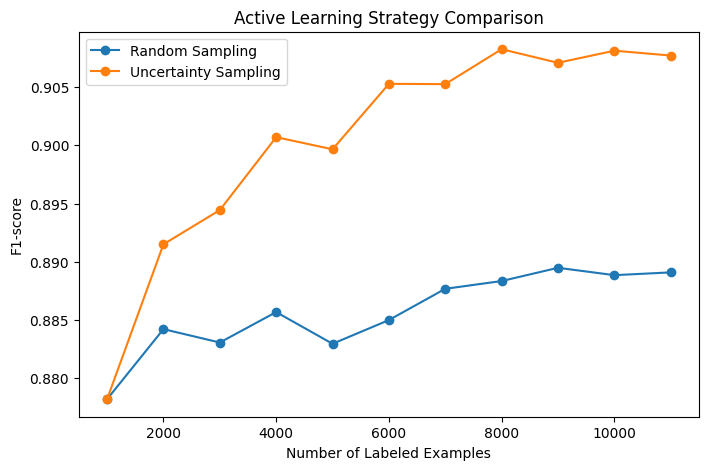

In [75]:
plt.figure(figsize=(8, 5))

for strategy in active_learning_results["strategy"].unique():
    strategy_results = active_learning_results[
        active_learning_results["strategy"] == strategy
    ]

    plt.plot(
        strategy_results["labeled_examples"],
        strategy_results["f1_score"],
        marker="o",
        label=strategy
    )

plt.xlabel("Number of Labeled Examples")
plt.ylabel("F1-score")
plt.title("Active Learning Strategy Comparison")
plt.legend()
plt.savefig("../visuals/active_learning_f1_comparison.png", bbox_inches="tight")
plt.show()

Cell 12: Plot recall comparison

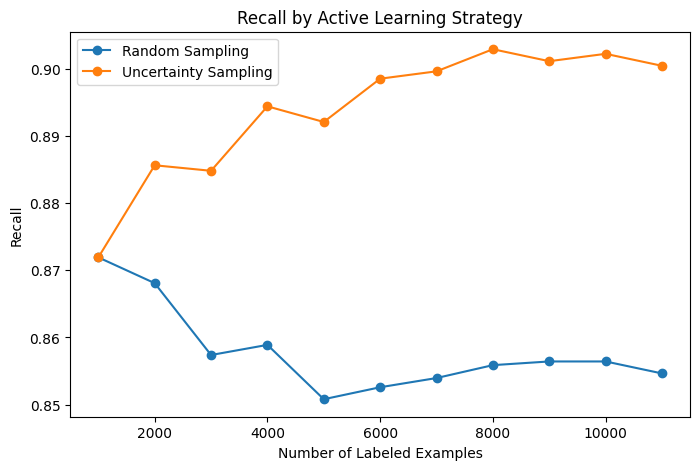

In [76]:
plt.figure(figsize=(8, 5))

for strategy in active_learning_results["strategy"].unique():
    strategy_results = active_learning_results[
        active_learning_results["strategy"] == strategy
    ]

    plt.plot(
        strategy_results["labeled_examples"],
        strategy_results["recall"],
        marker="o",
        label=strategy
    )

plt.xlabel("Number of Labeled Examples")
plt.ylabel("Recall")
plt.title("Recall by Active Learning Strategy")
plt.legend()
plt.savefig("../visuals/active_learning_recall_comparison.png", bbox_inches="tight")
plt.show()

Cell 13: Dissatisfied Recall Plot

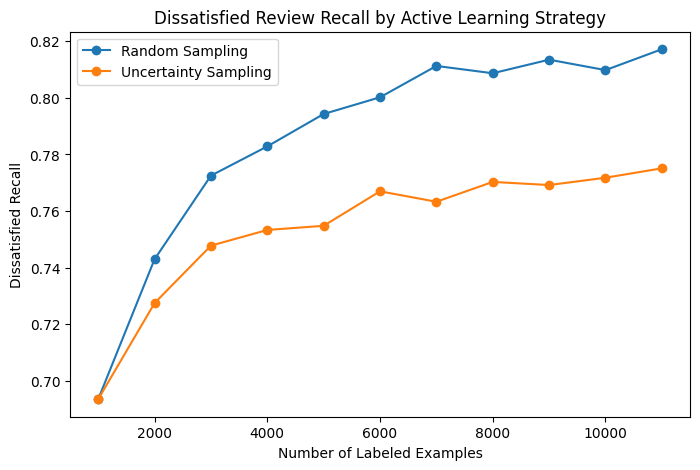

In [78]:
plt.figure(figsize=(8, 5))

for strategy in active_learning_results["strategy"].unique():
    strategy_results = active_learning_results[
        active_learning_results["strategy"] == strategy
    ]

    plt.plot(
        strategy_results["labeled_examples"],
        strategy_results["dissatisfied_recall"],
        marker="o",
        label=strategy
    )

plt.xlabel("Number of Labeled Examples")
plt.ylabel("Dissatisfied Recall")
plt.title("Dissatisfied Review Recall by Active Learning Strategy")
plt.legend()
plt.savefig("../visuals/active_learning_dissatisfied_recall_comparison.png", bbox_inches="tight")
plt.show()

## Active Learning Results Interpretation

The active learning simulation showed that uncertainty sampling and random sampling had different strengths. Both strategies began with the same initial labeled set, so their starting performance was identical. As more labeled examples were added, uncertainty sampling achieved a higher overall F1-score than random sampling, suggesting that selecting uncertain reviews helped improve general classification performance.

However, the class-specific recall results showed an important tradeoff. While uncertainty sampling improved overall F1-score and standard recall for the positive class (`Satisfied`), random sampling achieved higher recall for the `Dissatisfied` class. This means random sampling was better at identifying truly dissatisfied reviews in this experiment.

This distinction is important because dissatisfied reviews may be especially valuable in a guest satisfaction setting. These reviews can reveal issues with service, cleanliness, value, rooms, or other parts of the hotel experience. If the business goal is to improve overall satisfaction classification, uncertainty sampling may be useful. If the goal is specifically to catch more dissatisfied experiences, random sampling or a different active learning strategy may be more appropriate.

Overall, the results show that active learning is not just about improving one metric. The best labeling strategy depends on the goal of the model and which errors are most costly.

Cell 14: Final Comparison Table

In [79]:
# Compare final-round performance for each strategy.
final_active_learning_results = active_learning_results[
    active_learning_results["round"] == active_learning_results["round"].max()
]

final_active_learning_results[[
    "strategy",
    "labeled_examples",
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "dissatisfied_recall",
    "satisfied_recall"
]].round(4)

,strategy,labeled_examples,accuracy,precision,recall,f1_score,dissatisfied_recall,satisfied_recall
10,Random Sampling,11000,0.8445,0.9264,0.8546,0.8891,0.8172,0.8546
21,Uncertainty Sampling,11000,0.8665,0.9151,0.9004,0.9077,0.7751,0.9004


## Active Learning Summary

This experiment compared random sampling and uncertainty sampling for selecting new reviews to label. Both strategies started with the same initial labeled set and were evaluated on the same held-out test set.

Random sampling selected new examples randomly from the unlabeled pool, while uncertainty sampling selected examples where the model's predicted probability was closest to 0.50. These uncertain examples represent reviews where the model had the least confidence.

The results show how model performance changes as more labeled examples are added. This provides a practical way to evaluate whether active learning can improve label efficiency compared with randomly labeling more data.